# BEE 4750 Lab 2: Monte Carlo

**Name**: Evelyn Chen

**ID**: ec877

> **Due Date**
>
> Thursday, 10/02/25, 9:00pm

## Setup

The following code should go at the top of most Julia scripts; it will
load the local package environment and install any needed packages. You
will see this often and shouldn’t need to touch it.

In [2]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `~/BEE_4750/lab-2-ec8771`


In [4]:
using Random # random number generation
using Distributions # probability distributions and interface
using Statistics # basic statistical functions, including mean
using Plots # plotting

## Overview

In this lab, we will conduct a Monte Carlo experiment and explore how
sensitive Monte Carlo estimates are to the underlying probability
distribution(s).

You should always start any computing with random numbers by setting a
“seed,” which controls the sequence of numbers which are generated
(since these are not *really* random, just “pseudorandom”). In Julia, we
do this with the `Random.seed!()` function.

In [62]:
Random.seed!(1)

TaskLocalRNG()

It doesn’t matter what seed you set, though different seeds might result
in slightly different values. But setting a seed means every time your
notebook is run, the answer will be the same.

> **Seeds and Reproducing Solutions**
>
> If you don’t re-run your code in the same order or if you re-run the
> same cell repeatedly, you will not get the same solution. If you’re
> working on a specific problem, you might want to re-use
> `Random.seed()` near any block of code you want to re-evaluate
> repeatedly.

### Probability Distributions and Julia

Julia provides a common interface for probability distributions with the
[`Distributions.jl`
package](https://juliastats.org/Distributions.jl/stable/). The basic
workflow for sampling from a distribution is:

1.  Set up the distribution. The specific syntax depends on the
    distribution and what parameters are required, but the general call
    is the similar. For a normal distribution or a uniform distribution,
    the syntax is

    ``` julia
    # you don't have to name this "normal_distribution"
    # μ is the mean and σ is the standard deviation
    normal_distribution = Normal(μ, σ)
    # a is the upper bound and b is the lower bound; these can be set to +Inf or -Inf for an unbounded distribution in one or both directions.
    uniform_distribution = Uniform(a, b)
    ```

    There are lots of both
    [univariate](https://juliastats.org/Distributions.jl/stable/univariate/#Index)
    and
    [multivariate](https://juliastats.org/Distributions.jl/stable/multivariate/)
    distributions, as well as the ability to create your own, but we
    won’t do anything too exotic here.

2.  Draw samples. This uses the `rand()` command (which, when used
    without a distribution, just samples uniformly from the interval
    $[0, 1]$.) For example, to sample from our normal distribution
    above:

    ``` julia
    # draw n samples
    rand(normal_distribution, n)
    ```

Putting this together, let’s say that we wanted to simulate 100
six-sided dice rolls. We could use a [Discrete Uniform
distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.DiscreteUniform).

In [6]:
dice_dist = DiscreteUniform(1, 6) # can generate any integer between 1 and 6
dice_rolls = rand(dice_dist, 100) # simulate rolls

100-element Vector{Int64}:
 1
 3
 5
 4
 6
 2
 5
 5
 5
 2
 ⋮
 3
 6
 5
 5
 6
 3
 6
 6
 6

And then we can plot a histogram of these rolls:

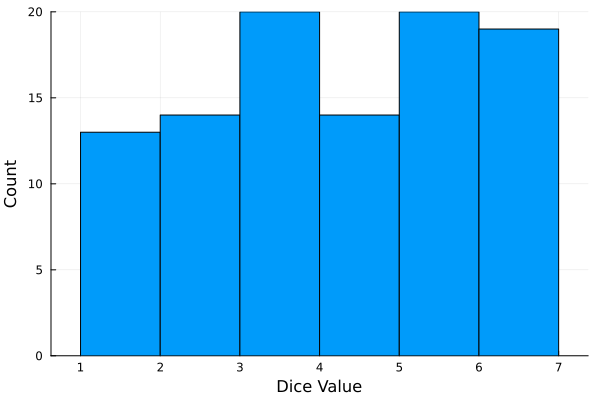

In [49]:
histogram(dice_rolls, legend=:false, bins=6)
ylabel!("Count")
xlabel!("Dice Value")

### Instructions

**Remember to**:

-   Evaluate all of your code cells, in order (using a `Run All`
    command). This will make sure all output is visible and that the
    code cells were evaluated in the correct order.
-   Tag each of the problems when you submit to Gradescope; a 10%
    penalty will be deducted if this is not done.

## Problem

A common engineering problem is to quantify flood risk, which is
typically computed by propagating a flood hazard distribution through a
*depth-damage function* relating flood depths to economic damages. A
reasonable depth-damage function for a house without a basement is a
bounded logistic function,
$$d(h) = \mathbb{1}_{h > 0} \frac{L}{1 + \exp(-k (h - h_0))},$$

where $d$ is the damage as a percent of total structure value, $h$ is
the water depth (relative to the house’s ground floor elevation) in m,
$\mathbb{1}_{x > 0}$ is the indicator function, $L$ is the maximum loss
in USD, $k$ is the slope of the depth-damage relationship, and $h_0$ is
the inflection point. We’ll assume $L=\$200,000$, $k=0.8$, and $h_0=3$.

For this problem, suppose that we have two different probability
distributions characterizing annual maxima flood depths:

1.  $h \sim LogNormal(1.2, 0.3)$;
2.  $h \sim GeneralizedExtremeValue(3, 0.9, -0.15)$.

Plot histograms of samples from these distributions and conduct a Monte
Carlo experiment for annual maximum flood damages using each. Answer the
following questions:

-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
-   How did you decide on your sample size?
-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

In [100]:
# Variables (given)
L  = 200_000 # max loss in USD
k  = 0.8 # slope of the depth-damage relationship
h_0 = 3.0 # inflection point

# Here, I simply copied the d(h) equation as it was shown to us, and wrote it as code.
function depth_damage_function(h, L, k, h0)
    return L / (1 + exp(-k*(h - h0)))
end

depth_damage_function (generic function with 2 methods)

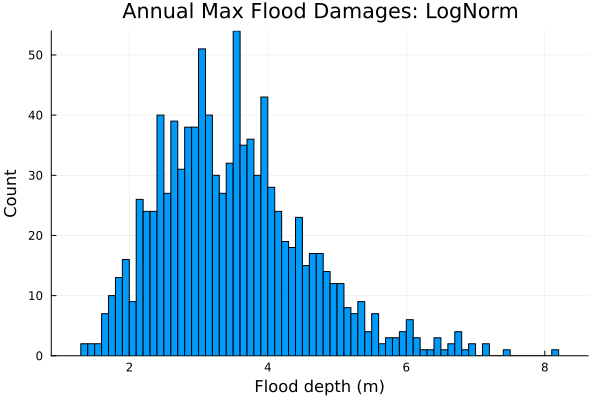

In [103]:
Random.seed!(1) #set random seed

# the first distribution is log normal distribution: lognormal(1.2,0.3)
# I chose to generate 1,000 random values in the sample
log_normal_distrib = LogNormal(1.2, 0.3)
samples_logn = rand(log_normal_distrib, 1_000) 

# created a histogram for the log normal distribution (bin 100 to make the histogram look better, as opposed to bin 1000)
histogram(samples_logn, legend=:false, bins=100, xlabel="Flood depth (m)", ylabel="Count", title="Annual Max Flood Damages: LogNorm")


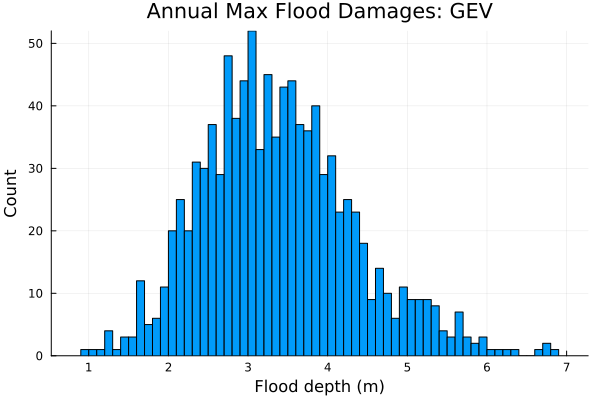

In [104]:
Random.seed!(1) #set random seed

# the second distribution is generalized extreme values distribution: generalizedextremevalue(3, 0.9, -0.15)
# I chose to generate 1,000 random values in the sample
gev_distrib = GeneralizedExtremeValue(3, 0.9, -0.15)
samples_gev = rand(gev_distrib, 1_000)

# created a histogram for the gev distribution (bin 100 to make the histogram look better, as opposed to bin 1000)
histogram(samples_gev, legend=:false, bins=100, xlabel="Flood depth (m)", ylabel="Count", title="Annual Max Flood Damages: GEV")


In [ ]:
# to analyze the statistics of the sample, I need to find the annual damages by running the values from the generated
# sample into the function depth_damage_function()

# for log normal distribution
run_logn = Float64[]
for h in samples_logn
    push!(run_logn, depth_damage_function(h, L, k, h_0))
end

mean_logn = mean(run_logn)
q99_logn  = quantile(run_logn, 0.99)

println("LogNormal: mean = ", mean_logn)
println("LogNormal: q99 = ", q99_logn)

# now for gev distribution
run_gev = Float64[]
for h in samples_gev
    push!(run_gev, depth_damage_function(h, L, k, h_0))
end

mean_gev = mean(run_gev)
q99_gev  = quantile(run_gev, 0.99)

println("GEV: mean = ", mean_gev)
println("GEV: q99 = ", q99_gev)


## 3. Discussion


-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?

  According to the log normal distribution, the Monte Carlo estimate of the expected value is ~$116408.54 (the mean), with the 99% quantile being ~$190698.95. According to the Generalized Extreme Values distribution, the Monte Carlo estimate is ~$112961.39, with the 99% quantile being ~$182530.21.

-   How did you decide on your sample size?

I chose 1,000 samples for each distribution (bin size 100)—honestly just an arbitrary value that didn't seem too small (which wouldn't give us very accurate values) or too large (which would take a long time to compile/run). A larger sample size would have made the estimates more accurate, but would have taken longer.

-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?

The estimates are similar but a bit varied between the two distributions, which is likely because the sample size wasn't large enough. It is likely that is the sample size was larger, the estimates for the two distributions might have been closer (and more precise). The differences in estimates might also be because of tail behavior. Given that the log normal distribution is better for data that have a long right tail but undersestimtates extreme events, while the generalized extreme values distribution (as per its name) is better for modelling extremes, this might also be another reason for why the estimates were a little different.

-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

Retrieving more flood data would be helpful in deciding which distribution is more accurate and precise. In addition, using strategies such as goodness of fit to check which distribution fits the observed floods more would also be helpful. Overall, given that log normal distributions underestimate extreme events, we can assume that the generalized extreme values distribution (as per its name) is better for modelling extremes. 


## References

Put any consulted sources here, including classmates you worked with/who
helped you.

I consulted online resources to learn more about the log normal distribution and the generalized extreme value distribution.